In [1]:

# Your NOAA CDO token (for Option A). Get one at https://www.ncdc.noaa.gov/cdo-web/token
CDO_TOKEN  = "cjfSWwpVZRryZPPZfkSDwbtDMZUJDYZZ"  # put your token here or set env var

# Optional: if you already know the GHCND station id for Vineyard Haven Airport,
# you can hardcode it (e.g., "GHCND:USW00014724"). If left None, we'll auto-discover.
HARDCODED_GHCND_STATION = "GHCND:USW00094724"



In [2]:
import os
import time
import math
from datetime import datetime, timedelta, date
from pathlib import Path
import requests
import pandas as pd

# =====================================================================
# USER CONFIG — fill these in
# =====================================================================

# Your NOAA CDO token (for Option A). Get one at https://www.ncdc.noaa.gov/cdo-web/token
CDO_TOKEN  = "cjfSWwpVZRryZPPZfkSDwbtDMZUJDYZZ"  # put your token here or set env var

STATION_ID  = "GHCND:USW00094724"               # <-- hard-code your GHCND station id (example from your log)
START_DATE  = "1980-01-01"                      # full period start
END_DATE    = "2026-04-01"                      # full period end

OUT_DIR     = Path("./cdo_prcp_chunks")         # each chunk (window) saved here
MASTER_CSV  = Path("./vineyard_haven_prcp_cdo_longterm.csv")  # final combined file

# Query parameters
WINDOW_DAYS   = 364  # strictly < 1 year to avoid 400 errors ("less than 1 year")
PAGE_LIMIT    = 1000 # CDO page size
RETRY_MAX     = 3    # per-request retries
RETRY_SLEEP_S = 5    # seconds between retries
RATE_SLEEP_S  = 0.2  # small pause per request to respect ~5 req/sec

# =====================================================================
# CONSTANTS / ENDPOINTS
# =====================================================================

CDO_BASE     = "https://www.ncei.noaa.gov/cdo-web/api/v2"
CDO_DATA     = f"{CDO_BASE}/data"

def _hdr(token: str) -> dict:
    return {"token": token.strip()}

# =====================================================================
# DATE UTILITIES
# =====================================================================

def to_date(s: str) -> date:
    return datetime.strptime(s, "%Y-%m-%d").date()

def windowize(start_str: str, end_str: str, window_days: int = WINDOW_DAYS):
    """
    Yield (start_date, end_date) tuples that cover the full range
    using strictly < 1-year windows (window_days = 364).
    """
    start = to_date(start_str)
    end   = to_date(end_str)
    if end < start:
        raise ValueError("END_DATE is before START_DATE.")

    cur = start
    while cur <= end:
        w_end = min(cur + timedelta(days=window_days), end)
        yield (cur, w_end)
        cur = w_end + timedelta(days=1)

# =====================================================================
# REQUEST WITH RETRIES
# =====================================================================

def cdo_get_with_retries(url: str, headers: dict, params: dict,
                         max_retry: int = RETRY_MAX,
                         sleep_s: float = RETRY_SLEEP_S):
    """
    GET with simple retry logic. Retries for transient HTTP errors (>=500) and 429.
    If still failing after retries, returns None.
    """
    attempt = 0
    while True:
        try:
            r = requests.get(url, headers=headers, params=params, timeout=60)
            # Special-case 400 to bubble up immediately (usually parameter/range issue)
            if r.status_code == 400:
                raise requests.HTTPError(f"400 Bad Request: {r.text}", response=r)
            # Handle 429 (rate limit): wait longer then retry
            if r.status_code == 429:
                time.sleep(max(sleep_s, 2.0))
                attempt += 1
                if attempt > max_retry:
                    return None
                continue
            # For 5xx, retry
            if 500 <= r.status_code < 600:
                attempt += 1
                if attempt > max_retry:
                    return None
                time.sleep(sleep_s)
                continue

            r.raise_for_status()
            return r
        except requests.RequestException as e:
            attempt += 1
            if attempt > max_retry:
                print(f"    ! Giving up after {max_retry} attempts: {e}")
                return None
            time.sleep(sleep_s)

# =====================================================================
# DOWNLOAD ONE WINDOW (handles pagination; saves immediately)
# =====================================================================

def download_window(token: str, stationid: str, start_date: date, end_date: date,
                    out_dir: Path, page_limit: int = PAGE_LIMIT) -> Path | None:
    """
    Downloads PRCP for a single window (strictly < 1 year), paginating until complete.
    Saves the window CSV immediately. Returns CSV path, or None if completely failed.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    out_csv = out_dir / f"{stationid.replace(':','_')}_PRCP_{start_date}_{end_date}.csv"

    # If this window already exists, skip re-download
    if out_csv.exists() and out_csv.stat().st_size > 0:
        print(f"    · Cached window exists: {out_csv.name}")
        return out_csv

    rows = []
    offset = 1

    while True:
        params = {
            "datasetid": "GHCND",
            "datatypeid": "PRCP",
            "stationid": stationid,
            "startdate": start_date.strftime("%Y-%m-%d"),
            "enddate":   end_date.strftime("%Y-%m-%d"),
            "units": "standard",
            "limit": page_limit,
            "offset": offset,
        }

        resp = cdo_get_with_retries(CDO_DATA, _hdr(token), params)
        if resp is None:
            # Could not fetch this page after retries — abort this window
            print(f"    ! Skipping window {start_date}..{end_date} due to repeated errors.")
            # Save what we have (even if empty) to mark the attempt and move on
            pd.DataFrame(rows).to_csv(out_csv, index=False)
            return None

        payload = resp.json()
        batch = payload.get("results", [])
        if not batch:
            # No more data pages — write out and finish
            break

        rows.extend(batch)

        # pagination metadata (count may be missing; handle robustly)
        meta_rs = payload.get("metadata", {}).get("resultset", {})
        count   = meta_rs.get("count", None)
        got     = len(rows)
        print(f"    · {start_date} → {end_date}: +{len(batch)}, total {got}{'' if count is None else f'/{count}'}")

        offset += page_limit
        time.sleep(RATE_SLEEP_S)

        if count is not None and got >= count:
            break

    # Save window CSV (even if empty)
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    print(f"    ✔ Saved window: {out_csv.name}  (rows={len(rows)})")
    return out_csv

# =====================================================================
# COMBINE ALL SAVED WINDOWS
# =====================================================================

def combine_windows(out_dir: Path, master_csv: Path):
    parts = sorted(out_dir.glob("*_PRCP_*.csv"))
    if not parts:
        print("No window CSVs found to combine.")
        return
    dfs = []
    for p in parts:
        try:
            df = pd.read_csv(p)
            if not df.empty:
                dfs.append(df)
        except Exception as e:
            print(f"    ! Could not read {p.name}: {e}")
    if not dfs:
        print("No non-empty CSVs to combine.")
        return
    df_all = pd.concat(dfs, ignore_index=True)
    keep = [c for c in ["date","value","datatype","station","attributes"] if c in df_all.columns]
    if keep:
        df_all = df_all[keep]
    df_all = df_all.sort_values("date")
    df_all.to_csv(master_csv, index=False)
    print(f"\n✔ Wrote combined file: {master_csv}  (rows={len(df_all)})")

# =====================================================================
# RUN: iterate windows, save each, then combine
# =====================================================================

print(f"[CDO] Station: {STATION_ID}")
print(f"[CDO] Period:  {START_DATE} .. {END_DATE}")
print(f"[CDO] Saving windows under: {OUT_DIR.resolve()}")

for (w_start, w_end) in windowize(START_DATE, END_DATE, WINDOW_DAYS):
    print(f"\n--> Window {w_start} .. {w_end}")
    download_window(CDO_TOKEN, STATION_ID, w_start, w_end, OUT_DIR)

# Combine all saved windows into one long-term CSV
combine_windows(OUT_DIR, MASTER_CSV)

[CDO] Station: GHCND:USW00094724
[CDO] Period:  1980-01-01 .. 2026-04-01
[CDO] Saving windows under: F:\crs\src\NOPP_comparison\cdo_prcp_chunks

--> Window 1980-01-01 .. 1980-12-30
    ✔ Saved window: GHCND_USW00094724_PRCP_1980-01-01_1980-12-30.csv  (rows=0)

--> Window 1980-12-31 .. 1981-12-30
    ✔ Saved window: GHCND_USW00094724_PRCP_1980-12-31_1981-12-30.csv  (rows=0)

--> Window 1981-12-31 .. 1982-12-30
    ✔ Saved window: GHCND_USW00094724_PRCP_1981-12-31_1982-12-30.csv  (rows=0)

--> Window 1982-12-31 .. 1983-12-30
    ✔ Saved window: GHCND_USW00094724_PRCP_1982-12-31_1983-12-30.csv  (rows=0)

--> Window 1983-12-31 .. 1984-12-29
    ✔ Saved window: GHCND_USW00094724_PRCP_1983-12-31_1984-12-29.csv  (rows=0)

--> Window 1984-12-30 .. 1985-12-29
    ✔ Saved window: GHCND_USW00094724_PRCP_1984-12-30_1985-12-29.csv  (rows=0)

--> Window 1985-12-30 .. 1986-12-29
    ✔ Saved window: GHCND_USW00094724_PRCP_1985-12-30_1986-12-29.csv  (rows=0)

--> Window 1986-12-30 .. 1987-12-29
    ✔ S

In [3]:
df = pd.read_csv( "vineyard_haven_prcp_cdo_longterm.csv" , parse_dates=["date"] )
df

,date,value,datatype,station,attributes
0,1998-04-01,0.27,PRCP,GHCND:USW00094724,",,W,"
1,1998-04-02,0.87,PRCP,GHCND:USW00094724,",,W,"
2,1998-04-03,0.00,PRCP,GHCND:USW00094724,",,W,"
3,1998-04-04,0.00,PRCP,GHCND:USW00094724,"T,,W,"
4,1998-04-05,0.00,PRCP,GHCND:USW00094724,"T,,W,"
...,...,...,...,...,...
10084,2026-03-28,0.00,PRCP,GHCND:USW00094724,"T,,d,"
10085,2026-03-29,0.00,PRCP,GHCND:USW00094724,",,d,"
10086,2026-03-30,0.00,PRCP,GHCND:USW00094724,",,d,"
10087,2026-03-31,0.00,PRCP,GHCND:USW00094724,"T,,d,"


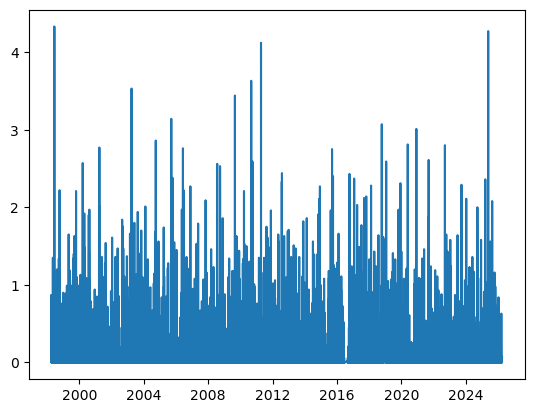

In [5]:
import matplotlib.pyplot as plt
plt.plot( df['date'],df['value'])

C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_47288\1337985436.py:29: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_sum = df["value"].resample("Y").sum()


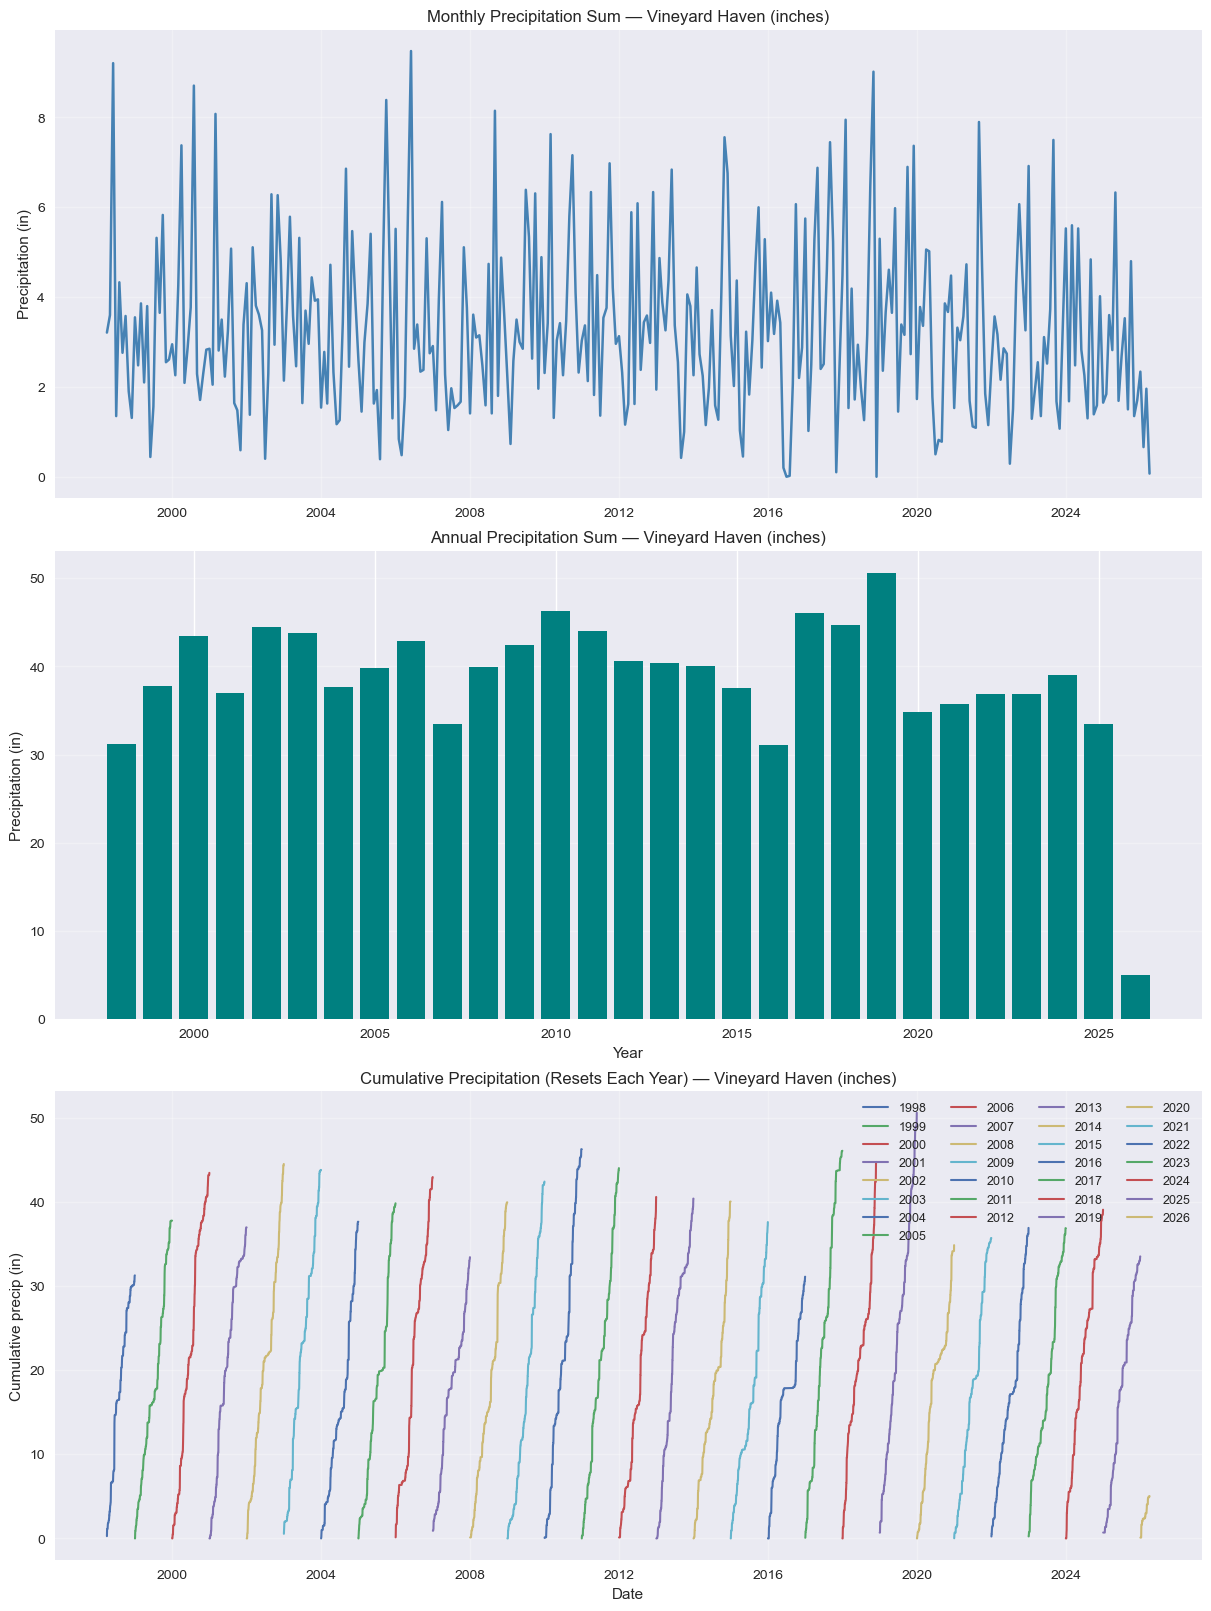

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# If you've already loaded df exactly as shown, you can skip this read_csv.
# df = pd.read_csv("vineyard_haven_prcp_cdo_longterm.csv", parse_dates=["date"])

# Ensure datetime index & clean daily duplicates
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])  # drop rows with bad/missing dates
df = df.sort_values("date")

# If a day appears more than once, sum it so daily totals are unique
# (Rare, but it happens if you concatenated multiple pulls.)
df = (
    df.groupby("date", as_index=False)
      .agg({"value":"sum", "datatype":"first", "station":"first", "attributes":"first"})
)

# Set index for resampling
df = df.set_index("date")

# ----- 1) Monthly sum of precipitation (inches) -----
monthly_sum = df["value"].resample("MS").sum()  # MS = Month Start
# Optional: keep only months with at least 1 day present
# monthly_sum = monthly_sum[df["value"].resample("MS").count() > 0]

# ----- 2) Annual sum of precipitation (inches) -----
annual_sum = df["value"].resample("Y").sum()

# ----- 3) Cumulative precipitation per year (resets Jan 1) -----
# Create a year column from the index; groupby year and cumsum
cum_per_year = df["value"].groupby(df.index.year).cumsum()

# ----------------- Plotting -----------------
plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(3, 1, figsize=(12, 16), constrained_layout=True)

# (1) Monthly sum
axes[0].plot(monthly_sum.index, monthly_sum.values, color="steelblue", lw=1.8)
axes[0].set_title("Monthly Precipitation Sum — Vineyard Haven (inches)")
axes[0].set_ylabel("Precipitation (in)")
axes[0].grid(True, alpha=0.3)

# (2) Annual sum (bar plot)
axes[1].bar(annual_sum.index.year, annual_sum.values, color="teal", width=0.8)
axes[1].set_title("Annual Precipitation Sum — Vineyard Haven (inches)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Precipitation (in)")
axes[1].grid(True, axis="y", alpha=0.3)

# (3) Cumulative precipitation per year (line plot that resets each year)
# We’ll plot each year separately for clarity
for yr, grp in df["value"].loc[df.index.year >= df.index.min().year].groupby(df.index.year):
    # Align to that year's dates
    grp_dates = grp.index
    grp_cum = grp.cumsum()
    axes[2].plot(grp_dates, grp_cum, lw=1.5, label=str(yr))

axes[2].set_title("Cumulative Precipitation (Resets Each Year) — Vineyard Haven (inches)")
axes[2].set_ylabel("Cumulative precip (in)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncol=4, fontsize=9, framealpha=0.2)

plt.show()

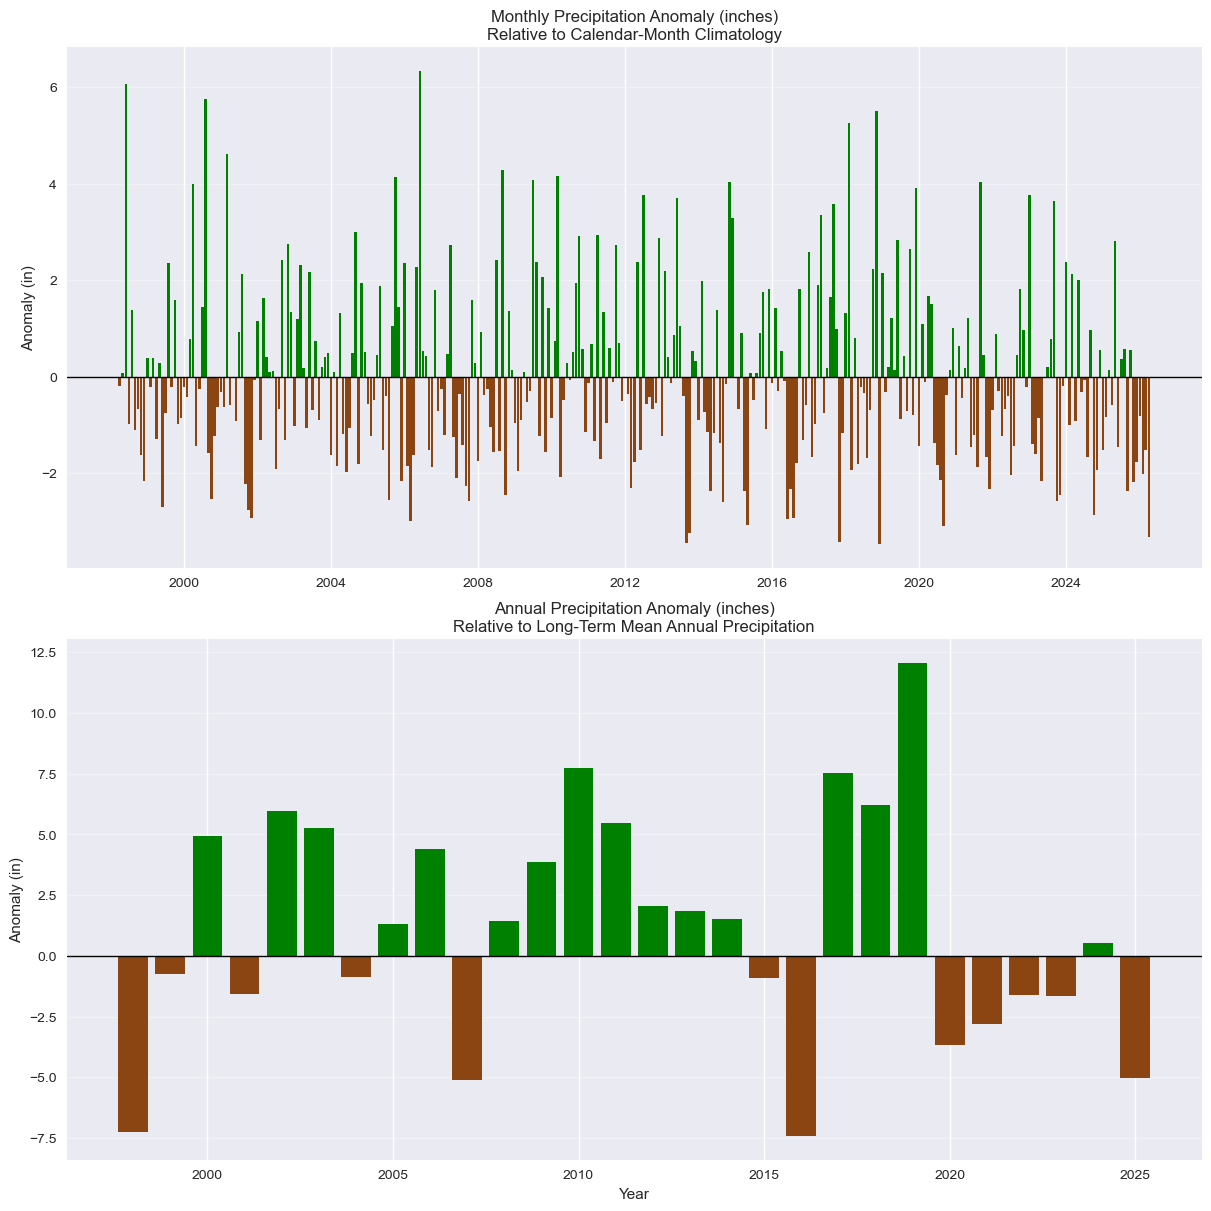

Monthly climatology (in):
01    3.161071
02    2.684643
03    3.471786
04    3.397931
05    3.521071
06    3.144286
07    2.323214
08    2.955357
09    3.864286
10    4.249643
11    3.522500
12    3.467500
Name: value, dtype: float64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Assumes df already loaded as:
# df = pd.read_csv("vineyard_haven_prcp_cdo_longterm.csv", parse_dates=["date"])
df = pd.read_csv( "vineyard_haven_prcp_cdo_longterm.csv" , parse_dates=["date"] )

# 1) Clean and prepare daily series
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date")

# If there are duplicate dates (e.g., multiple pulls concatenated), aggregate to a single daily total
df = (
    df.groupby("date", as_index=False)
      .agg({"value":"sum", "datatype":"first", "station":"first", "attributes":"first"})
)
df = df.set_index("date")

# 2) Build monthly and annual sums
monthly_sum = df["value"].resample("MS").sum()    # Month-start frequency
annual_sum  = df["value"].resample("YE").sum()     # Year-end frequency (Dec 31)

# 3) Long-term means (climatologies)
# Monthly climatology: mean of each calendar month across all years
monthly_climo = monthly_sum.groupby(monthly_sum.index.month).mean()  # 1..12
# Map that climatology back to the monthly_sum index
monthly_mean_for_each_point = monthly_sum.index.month.map(monthly_climo)
monthly_anom = monthly_sum - monthly_mean_for_each_point

# Annual mean precipitation
annual_mean = annual_sum.mean()
annual_anom = annual_sum - annual_mean

# 4) Plotting: anomaly bars (brown for <0, green for >0)
plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(2, 1, figsize=(12, 12), constrained_layout=True)

# ----- Monthly anomaly -----
colors_month = ["green" if v >= 0 else "saddlebrown" for v in monthly_anom.values]
axes[0].bar(monthly_anom.index, monthly_anom.values, color=colors_month, width=25)  # width ~ days
axes[0].axhline(0, color="k", lw=1)
axes[0].set_title("Monthly Precipitation Anomaly (inches)\nRelative to Calendar-Month Climatology")
axes[0].set_ylabel("Anomaly (in)")
axes[0].grid(True, axis="y", alpha=0.3)

# Add a subtle reference: the long-term monthly mean line for the current month isn't needed,
# but if you want to annotate, you can use monthly_climo.

# ----- Annual anomaly -----
# Bar labels on x-axis by year
years = annual_anom.index.year
colors_year = ["green" if v >= 0 else "saddlebrown" for v in annual_anom.values]
axes[1].bar(years[:-1], annual_anom.values[:-1], color=colors_year[:-1], width=0.8)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_title("Annual Precipitation Anomaly (inches)\nRelative to Long-Term Mean Annual Precipitation")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Anomaly (in)")
axes[1].grid(True, axis="y", alpha=0.3)

plt.show()

# (Optional) Print the reference means used
print("Monthly climatology (in):")
print(pd.Series(monthly_climo, index=range(1,13)).rename(index=lambda m: f"{m:02d}"))



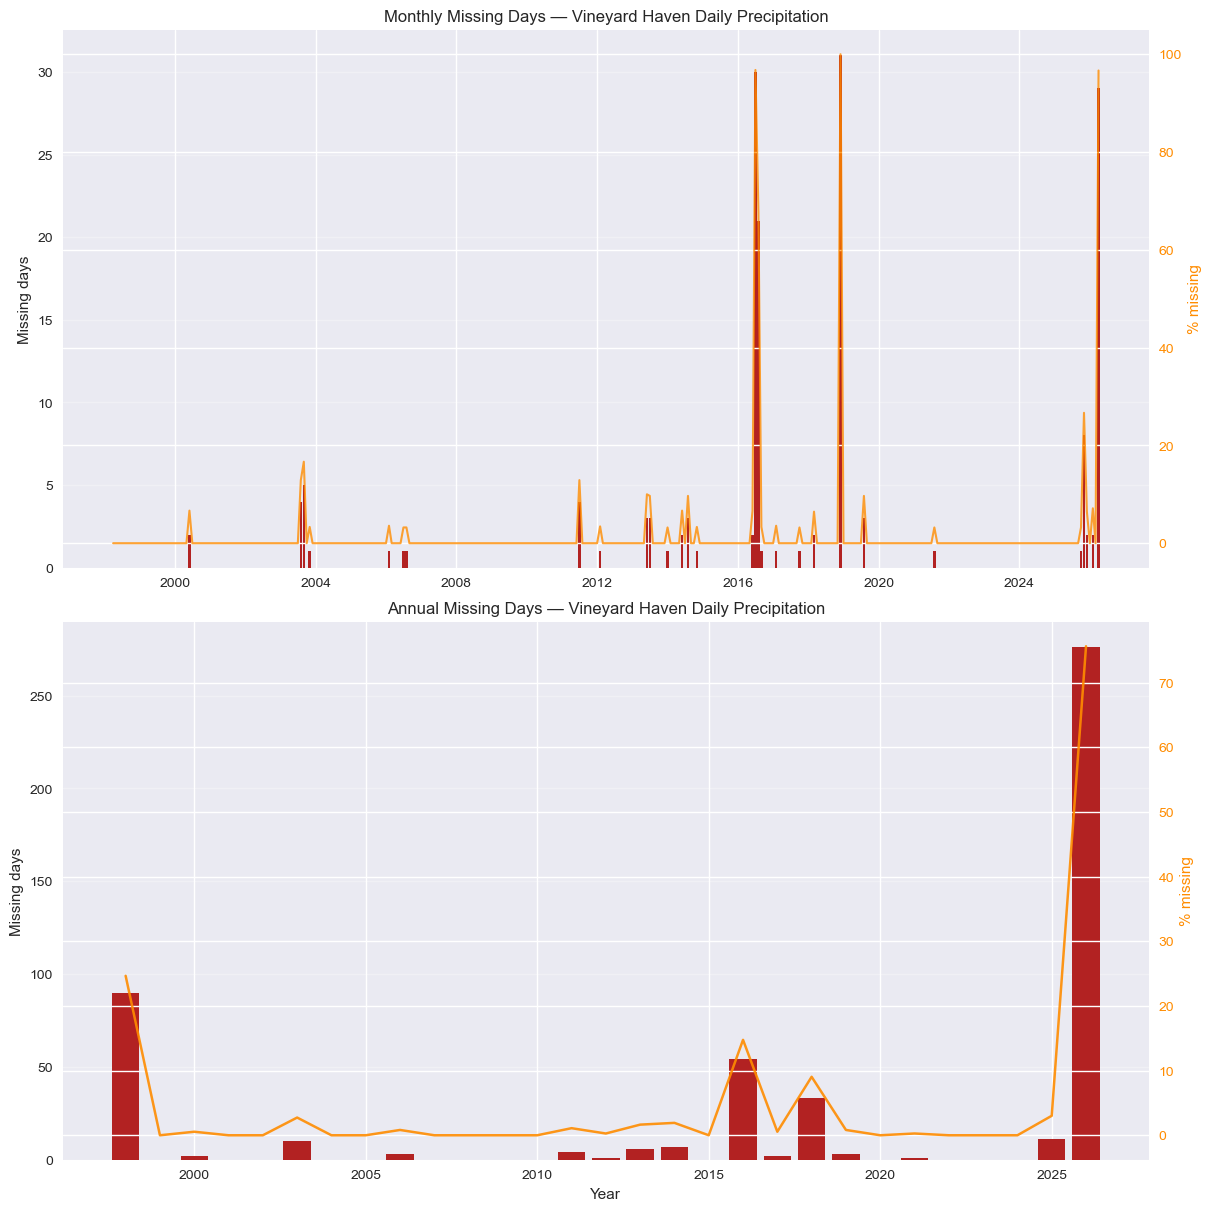


Monthly missing-days summary (first 12 rows):
             days_present  days_expected  days_missing  pct_missing
month_start                                                        
1998-04-01             30             30             0          0.0
1998-05-01             31             31             0          0.0
1998-06-01             30             30             0          0.0
1998-07-01             31             31             0          0.0
1998-08-01             31             31             0          0.0
1998-09-01             30             30             0          0.0
1998-10-01             31             31             0          0.0
1998-11-01             30             30             0          0.0
1998-12-01             31             31             0          0.0
1999-01-01             31             31             0          0.0
1999-02-01             28             28             0          0.0
1999-03-01             31             31             0          0.0



In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0) Start from your already-loaded DataFrame
#     df = pd.read_csv("vineyard_haven_prcp_cdo_longterm.csv", parse_dates=["date"])
# ---------------------------------------------------------------------
df = pd.read_csv( "vineyard_haven_prcp_cdo_longterm.csv" , parse_dates=["date"] )
# Clean, sort, and ensure unique daily dates (sum duplicates if any)
work = df.copy()
work["date"] = pd.to_datetime(work["date"], errors="coerce")
work = work.dropna(subset=["date"]).sort_values("date")

# If the same calendar day appears multiple times (e.g., concatenated pulls), sum it
work = (work.groupby("date", as_index=False)
              .agg({"value": "sum",
                    "datatype": "first", "station": "first", "attributes": "first"}))

work = work.set_index("date")

# ---------------------------------------------------------------------
# 1) Build a full daily calendar between min and max date
#    Mark presence (1) / absence (0) for each day
# ---------------------------------------------------------------------
full_range = pd.date_range(start=work.index.min(), end=work.index.max(), freq="D")
present = pd.Series(1, index=work.index)               # 1 for days we have
present = present.reindex(full_range, fill_value=0)    # fill missing calendar days with 0
present.name = "present"

# ---------------------------------------------------------------------
# 2) Monthly analysis: counts, expected days, missing days & %
# ---------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Monthly analysis (unchanged logic; kept for completeness) ---
monthly_present = present.resample("MS").sum()  # Month-start labels
monthly_expected = pd.Index(monthly_present.index).to_period("M").days_in_month
monthly_missing = monthly_expected - monthly_present

monthly_df = pd.DataFrame({
    "month_start": monthly_present.index,
    "days_present": monthly_present.values.astype(int),
    "days_expected": monthly_expected.astype(int),
    "days_missing": monthly_missing.values.astype(int),
    "pct_missing": (monthly_missing / monthly_expected * 100.0)
}).set_index("month_start")

# --- Annual analysis (fixed) ---
# Use YE (year-end) to match your previous behavior (bars labeled by ending year)
annual_present = present.resample("YE").sum()

# Get a PeriodIndex of years and use is_leap_year to set expected days
annual_periods = annual_present.index.to_period("Y")
annual_expected = pd.Series(
    np.where(annual_periods.is_leap_year, 366, 365),
    index=annual_present.index
)

annual_missing = annual_expected - annual_present

annual_df = pd.DataFrame({
    "year": annual_present.index.year,                 # label bars by year
    "days_present": annual_present.values.astype(int),
    "days_expected": annual_expected.values.astype(int),
    "days_missing": annual_missing.values.astype(int),
    "pct_missing": (annual_missing / annual_expected * 100.0)
}).set_index("year")

# --- Plotting ---
plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(2, 1, figsize=(12, 12), constrained_layout=True)

# Monthly missing days
axes[0].bar(monthly_df.index, monthly_df["days_missing"], color="firebrick", width=25)
axes[0].set_title("Monthly Missing Days — Vineyard Haven Daily Precipitation")
axes[0].set_ylabel("Missing days")
axes[0].grid(True, axis="y", alpha=0.3)
ax2 = axes[0].twinx()
ax2.plot(monthly_df.index, monthly_df["pct_missing"], color="darkorange", lw=1.5, alpha=0.8)
ax2.set_ylabel("% missing", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Annual missing days
axes[1].bar(annual_df.index, annual_df["days_missing"], color="firebrick", width=0.8)
axes[1].set_title("Annual Missing Days — Vineyard Haven Daily Precipitation")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Missing days")
axes[1].grid(True, axis="y", alpha=0.3)
ax3 = axes[1].twinx()
ax3.plot(annual_df.index, annual_df["pct_missing"], color="darkorange", lw=1.8, alpha=0.9)
ax3.set_ylabel("% missing", color="darkorange")
ax3.tick_params(axis="y", labelcolor="darkorange")

plt.show()

print("\nMonthly missing-days summary (first 12 rows):")
print(monthly_df.head(12).round({"pct_missing": 2}))

print("\nAnnual missing-days summary:")
print(annual_df.round({"pct_missing": 2}))

# ---------------------------------------------------------------------
# 5) Print summaries
# ---------------------------------------------------------------------
print("\nMonthly missing-days summary (first 12 rows):")
print(monthly_df.head(12).round({"pct_missing": 2}))

print("\nAnnual missing-days summary:")
print(annual_df.round({"pct_missing": 2}))